In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [54]:
df=pd.read_csv("smartcart_customers.csv")

In [ ]:
df.head() 

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [56]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

## Handle Missing value

In [57]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [58]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## Feature Engineering

In [59]:
# Age
df["Age"]=2026-df["Year_Birth"]

In [60]:
df["Age"].head()

0    69
1    72
2    61
3    42
4    45
Name: Age, dtype: int64

In [61]:
# Customer joining Date
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)

reference_date=df["Dt_Customer"].max()

df["Customer_Tenure_Days"]=(reference_date-df["Dt_Customer"]).dt.days

In [62]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [63]:
# Spending

df["Total_Spending"]=df["MntWines"] + df["MntFruits"]+df["MntMeatProducts"] + df["MntFishProducts"]+df["MntSweetProducts"] + df["MntGoldProds"]

In [64]:
# Childern
df["Total_Child"]=df["Kidhome"] + df["Teenhome"]

In [65]:
df["Total_Child"].head()

0    0
1    2
2    0
3    1
4    1
Name: Total_Child, dtype: int64

In [66]:
# Education

df["Education"].value_counts()

# Undergraduate, Graduate,Postgraduate

df["Education"]=df["Education"].replace({
    "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "PhD":"Postgraduate",
    "Master":"Postgraduate"
})

In [67]:
# Marital Status

df["Living_With"]=df["Marital_Status"].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Absurd":"Alone",
    "YOLO":"Alone",
})

In [68]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

## Drop Unnecessary Columns

In [69]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols=["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop= cols + spending_cols

df_cleaned=df.drop(columns=cols_to_drop)

In [70]:
df_cleaned.shape

(2240, 15)

In [71]:
df.shape

(2240, 27)

In [72]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Child,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


 # Outliers

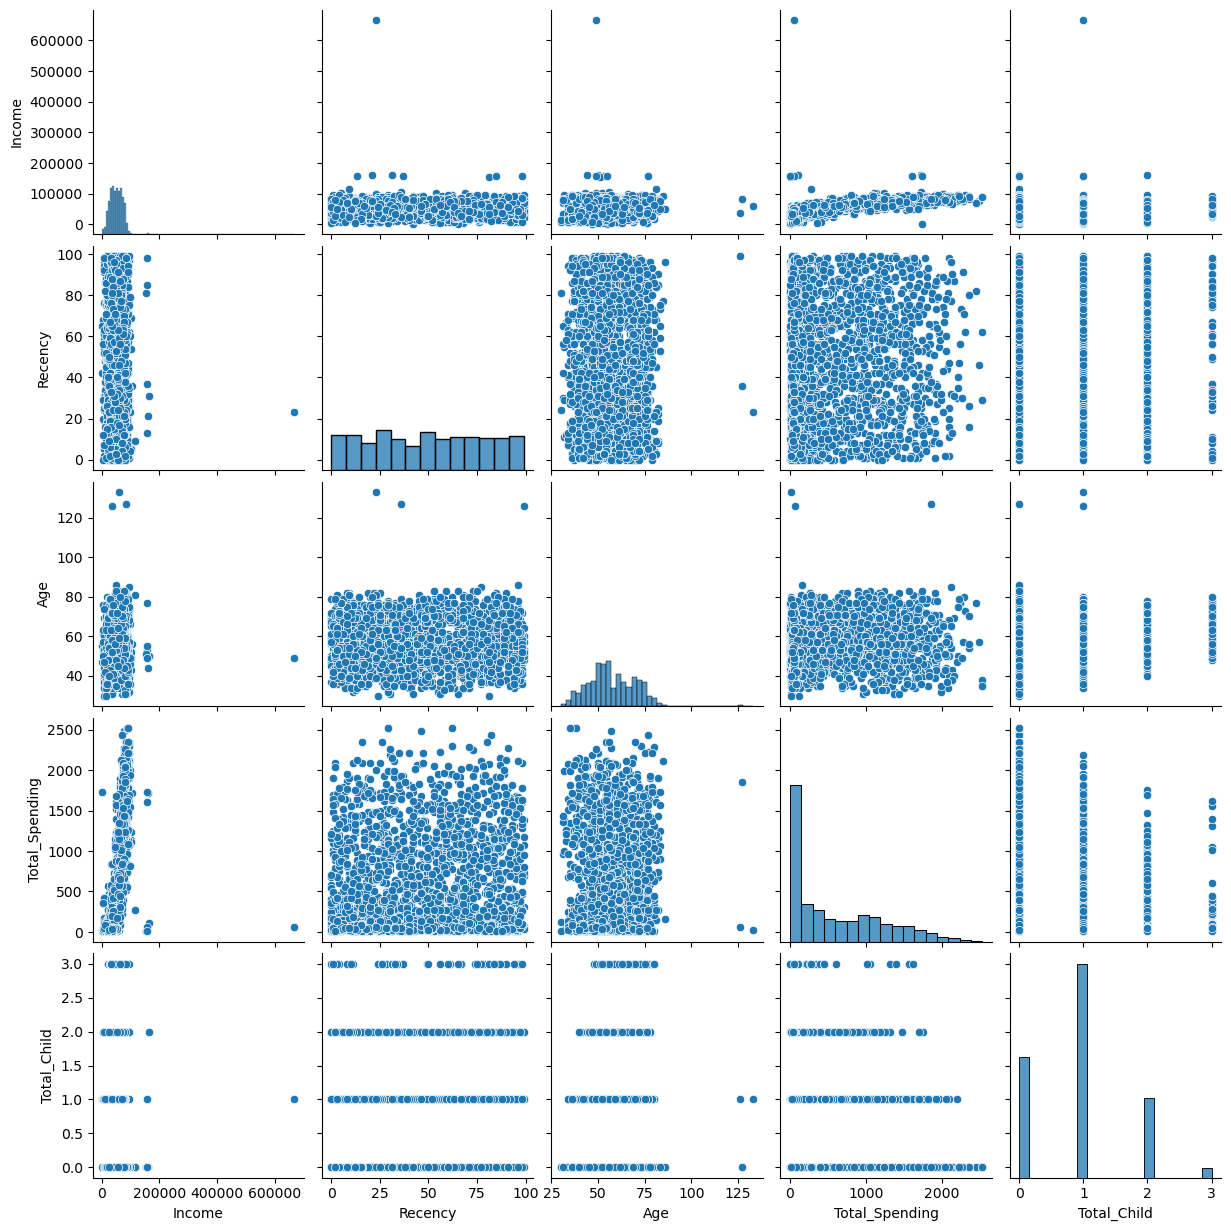

In [73]:
cols=["Income","Recency","Age","Total_Spending","Total_Child"]

# Relitive plots of some features
sns.pairplot(df_cleaned[cols])

In [74]:
# Remove Outliers

print("Data size with Outliers",len(df_cleaned))

df_cleaned=df_cleaned[df_cleaned["Age"]<90]
df_cleaned=df_cleaned[df_cleaned["Income"]<600_000]

print("Data without Outliers",len(df_cleaned))

Data size with Outliers 2240
Data without Outliers 2236


# Heatmap

In [75]:
corr=df_cleaned.corr(numeric_only=True)

<Axes: >

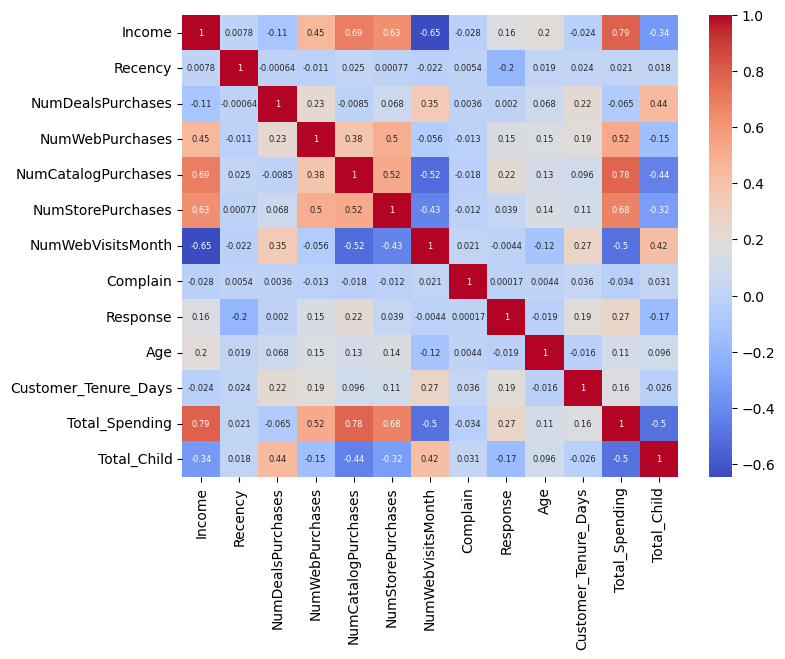

In [76]:
plt.figure(figsize=(8,6)) 
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

In [77]:
df_cleaned.shape

(2236, 15)

In [78]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Child,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Encoding

In [79]:
from sklearn.preprocessing import OneHotEncoder


In [80]:
ohe=OneHotEncoder()

cat_cols=["Education","Living_With"]

enc_cols=ohe.fit_transform(df_cleaned[cat_cols])

In [81]:
enc_df=pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [82]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [83]:
df_encoded.shape

(2236, 18)

In [84]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Child,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling Data

In [85]:
from sklearn.preprocessing import StandardScaler

In [86]:
X=df_encoded

In [87]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [88]:
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

# Visulize Data

In [89]:
X_scaled.shape

(2236, 18)

## 2D

In [90]:
# 2D
from sklearn.decomposition import PCA

In [91]:
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

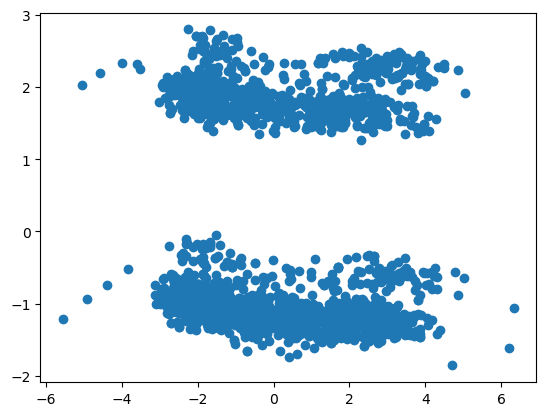

In [92]:
# Plot

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
)

In [94]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

## 3D

Text(0.5, 0.92, '3D Projection')

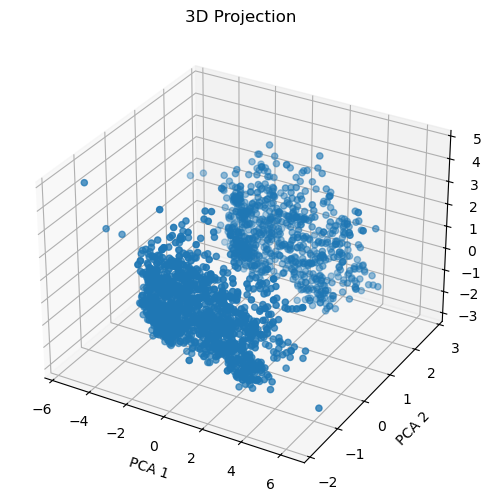

In [99]:
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_scaled)
# Plot
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")
ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2]
)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("3D Projection")

In [100]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# Analyze K Values
## 1 - Elbow Method

In [107]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [108]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow

In [109]:
print("Best K :",optimal_k)

Best K : 4


Text(0, 0.5, 'WSCC')

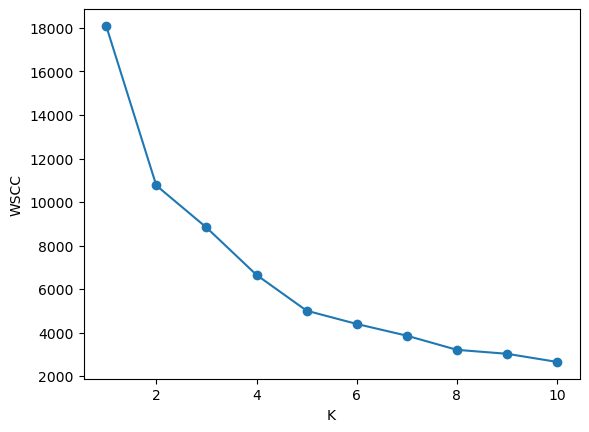

In [110]:
# Plot
plt.plot(
    range(1,11),
    wcss,
    marker="o"
)
plt.xlabel("K")
plt.ylabel("WSCC")

## 2 - Silhouette Score

Text(0, 0.5, 'Silhouette score')

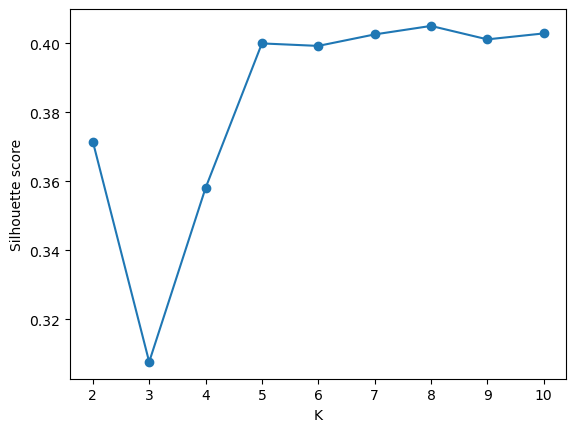

In [116]:
from sklearn.metrics import silhouette_score
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)
# Plot
plt.plot(
    range(2,11),
    scores,
    marker="o"
)
plt.xlabel("K")
plt.ylabel("Silhouette score")

Text(0, 0.5, 'silhouette score')

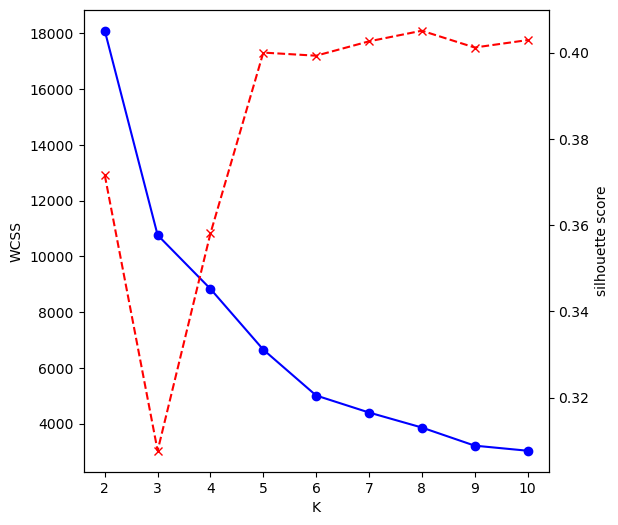

In [122]:
# combin plot
k_range=range(2,11)
fig,ax=plt.subplots(figsize=(6,6))

ax.plot(k_range,wcss[:len(k_range)],marker="o",c="blue")
ax.set_xlabel("K")
ax.set_ylabel("WCSS")

ax2=ax.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",c="red",linestyle="--")
ax2.set_ylabel("silhouette score")

# Clustring Algorthm

## 1 - K_means

In [124]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=4,random_state=42)
label_kmeans=kmeans.fit_predict(X_pca)

Text(0.5, 0.92, '3D Projection')

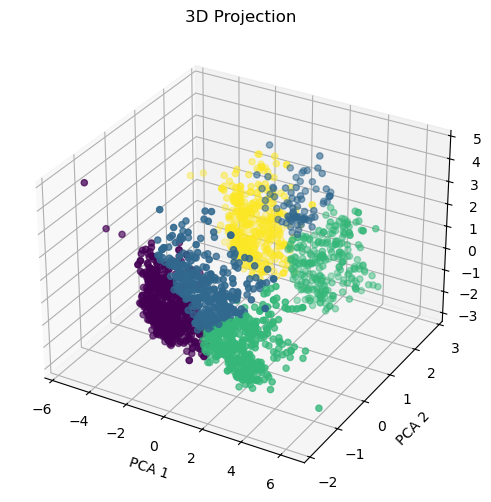

In [125]:
# Plot
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")
ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=label_kmeans
)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("3D Projection")

## 2 - Agglomerative clustring

In [127]:
from sklearn.cluster import AgglomerativeClustering

In [131]:
agg_clf=AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)
labels_agg=agg_clf.fit_predict(X_pca)

Text(0.5, 0.92, '3D Projection')

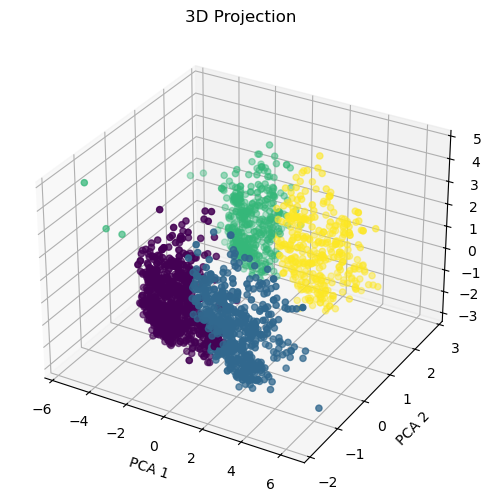

In [132]:
# Plot
fig=plt.figure(figsize=(8,6))

ax=fig.add_subplot(111,projection="3d")
ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=labels_agg
)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")
ax.set_title("3D Projection")

# Characterization Of Clusters

In [140]:

X["cluster"]=labels_agg

In [141]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Child,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

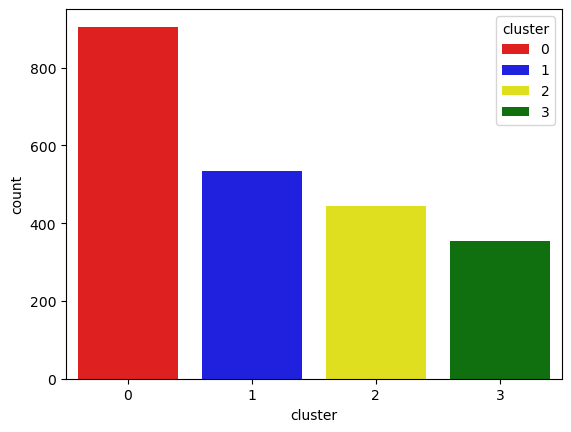

In [142]:
pal=["red","blue","yellow","green"]

sns.countplot(
    x=X["cluster"],
    palette=pal,
    hue=X["cluster"]
)

<Axes: xlabel='Total_Spending', ylabel='Income'>

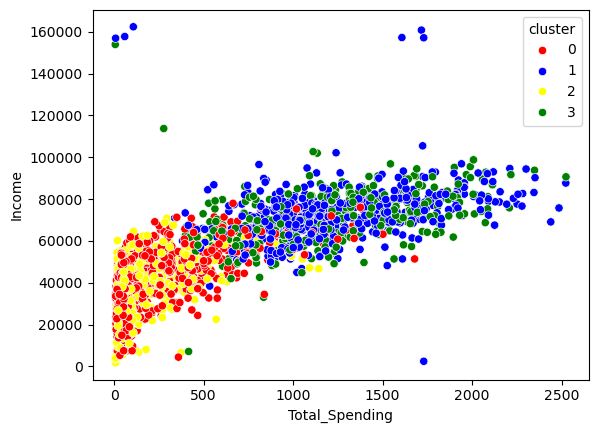

In [143]:
# Income & Spending patterns
sns.scatterplot(
    x=X["Total_Spending"],
    y=X["Income"],
    hue=X["cluster"],
    palette=pal
)

# Cluster Summary

In [145]:
cluster_summary=X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         